# **Medical Text Classification using Bi-Directional LSTM**

### **Project Objective**

The objective of this project is to build a clinical text classification system using a **Bi-Directional LSTM (BiLSTM)** architecture to classify medical transcriptions into disease or specialty-related categories. The goal is to convert unstructured clinical notes into contextual sequence representations so that the model can learn subtle medical language patterns, terminology, and diagnostic cues that distinguish one category from another. This project demonstrates how sequence models can support practical healthcare NLP tasks such as document triage, specialty routing, medical coding assistance, and automated clinical text organization.

### **Dataset Used**

The dataset used in this project is based on the **Medical Transcriptions** dataset, available at:

**Dataset Link:** https://www.kaggle.com/datasets/c/medical-transcriptions

This dataset typically contains healthcare transcription text along with associated medical specialties or categories. Each record generally includes:

- **description / category / specialty** → the target clinical class  
- **transcription / medical text** → the raw clinical note or transcription text  

In this notebook, the dataset is used as the core labeled corpus for supervised text classification. The workflow includes:

- loading and inspecting the raw medical text records  
- standardizing text and label columns  
- cleaning clinical note text while preserving medical content  
- analyzing category imbalance and note length distribution  
- tokenizing text into sequences  
- training a BiLSTM classifier with class imbalance handling  
- optionally adding an **attention layer** on top of BiLSTM  
- evaluating the model using accuracy, precision, recall, F1-score, confusion matrix, and sample error analysis  

Because clinical text often contains abbreviations, irregular structure, and specialized vocabulary, the dataset is especially well suited for contextual sequence modeling. The label distribution can also be imbalanced, which makes it useful for demonstrating practical handling of skewed healthcare data.

### **Project Summary**

This project develops an end-to-end **clinical NLP classification pipeline** using a Bi-Directional LSTM model. The notebook begins by loading and profiling the medical transcription dataset, inspecting specialty distribution, transcription lengths, and data quality. It then cleans the text, tokenizes the clinical notes, pads sequences, and prepares train, validation, and test splits.

The core model uses an embedding layer followed by a **BiLSTM encoder**, which reads the sequence in both forward and backward directions. This is particularly valuable in clinical text because meaning often depends on surrounding context, such as symptom mentions, medication references, or diagnostic qualifiers. An optional lightweight attention mechanism is added on top of the BiLSTM to help the model focus on the most informative parts of the note.

The project also emphasizes real-world evaluation. In addition to classification metrics such as accuracy and weighted F1, it includes class distribution analysis, category-wise error inspection, confusion matrix review, confidence-based prediction analysis, and misclassification examples. This makes the notebook closer to an applied healthcare NLP workflow rather than a simple tutorial.

The final notebook also includes reusable inference utilities, model saving and reload validation, prediction exports, and an optional demo section. As a result, the project serves as both a strong portfolio artifact and a realistic demonstration of how BiLSTM models can support clinical text understanding.

### **Key Highlights**

- Built a **medical text classification system** using **Bi-Directional LSTM** for clinical NLP.
- Used the **Medical Transcriptions** dataset as the labeled corpus for specialty/disease-style classification.
- Performed detailed **dataset exploration**, including class imbalance analysis and transcription length analysis.
- Implemented **text cleaning, tokenization, vocabulary building, and padded sequence preprocessing**.
- Added **class imbalance handling** to improve robustness on uneven clinical category distributions.
- Built a **BiLSTM classifier** and included an **attention mechanism** to improve context-sensitive learning.
- Evaluated the model using **accuracy, precision, recall, F1-score, confusion matrix, and class-wise analysis**.
- Added **prediction confidence analysis** and **error inspection** to identify difficult medical classes.
- Included **sample outputs**, **model save/reload validation**, and an optional **deployment demo** section.
- Preserved a modular structure so the notebook can be extended into healthcare document routing or coding-assistance systems.


### **Install Required Libraries**

In [1]:
!pip -q install -U pandas numpy matplotlib scikit-learn nltk ipywidgets tensorflow keras

### **Import Core Libraries**

In [2]:
import os
import gc
import re
import json
import math
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")

### **Notebook Display Settings**

In [3]:
pd.set_option("display.max_colwidth", 240)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

### **Set Reproducibility Seed**

In [4]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Seed set to:", SEED)

Seed set to: 42


### **Create Project Folders**

In [5]:
PROJECT_DIR = Path("./medical_text_classification_bilstm_project")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
MODEL_DIR = PROJECT_DIR / "saved_model"
PRED_DIR = PROJECT_DIR / "predictions"

for folder in [PROJECT_DIR, ARTIFACT_DIR, MODEL_DIR, PRED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


### **Define Project Configuration**

In [6]:
DATA_ROOT = Path("./medical_transcriptions_data")
DATA_FILE = DATA_ROOT / "medical_transcriptions.csv"

MAX_VOCAB_SIZE = 30000
MAX_SEQ_LEN = 300
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.30
BATCH_SIZE = 32
EPOCHS = 5
MIN_CLASS_COUNT = 2

print("Configuration ready.")

Configuration ready.


### **State the Real-World Problem**

In [7]:
problem_statement = '''
Healthcare organizations generate large volumes of unstructured clinical notes. Manually routing these
documents to the right specialty or disease group is slow and error-prone. This project addresses that
problem by building a BiLSTM-based classifier that learns medical language patterns and automatically
categorizes clinical transcriptions into the correct class.
'''
print(problem_statement)


Healthcare organizations generate large volumes of unstructured clinical notes. Manually routing these
documents to the right specialty or disease group is slow and error-prone. This project addresses that
problem by building a BiLSTM-based classifier that learns medical language patterns and automatically
categorizes clinical transcriptions into the correct class.



### **Show Expected Dataset Structure**

In [8]:
expected_structure = '''
medical_transcriptions_data/
└── medical_transcriptions.csv

Common columns may include:
- medical_specialty
- transcription
- description
'''
print(expected_structure)


medical_transcriptions_data/
└── medical_transcriptions.csv

Common columns may include:
- medical_specialty
- transcription
- description



### **Create a Small Placeholder Dataset if Missing**

In [9]:
if not DATA_FILE.exists():
    DATA_ROOT.mkdir(parents=True, exist_ok=True)

    sample_df = pd.DataFrame({
        "medical_specialty": [
            "Cardiology", "Cardiology", "Neurology", "Neurology",
            "Orthopedic", "Orthopedic", "Radiology", "Radiology",
            "Gastroenterology", "Gastroenterology"
        ],
        "transcription": [
            "Patient presents with chest pain and shortness of breath. ECG changes suggest ischemic heart disease.",
            "History of hypertension and palpitations. Echocardiogram recommended for further evaluation.",
            "Patient reports recurrent headaches and dizziness with possible migraine symptoms.",
            "Neurological examination indicates weakness in the right upper limb and sensory deficits.",
            "Knee pain worsened with movement. MRI suggests meniscal injury and ligament strain.",
            "Fracture follow-up note showing stable alignment and improving range of motion.",
            "Chest x ray shows mild bilateral infiltrates with no pleural effusion.",
            "CT scan demonstrates no acute intracranial hemorrhage and stable ventricular size.",
            "Patient complains of abdominal pain, reflux symptoms, and nausea after meals.",
            "Endoscopy findings show gastritis and mild esophageal inflammation."
        ]
    })

    sample_df.to_csv(DATA_FILE, index=False)
    print("Created a placeholder dataset for notebook structure.")
else:
    print("Dataset file already exists.")

Dataset file already exists.


### **Load the Medical Dataset**

In [10]:
df = pd.read_csv(DATA_FILE)
print(df.shape)
df.head()

(10, 2)


,medical_specialty,transcription
0,Cardiology,Patient presents with chest pain and shortness of breath. ECG changes suggest ischemic heart disease.
1,Cardiology,History of hypertension and palpitations. Echocardiogram recommended for further evaluation.
2,Neurology,Patient reports recurrent headaches and dizziness with possible migraine symptoms.
3,Neurology,Neurological examination indicates weakness in the right upper limb and sensory deficits.
4,Orthopedic,Knee pain worsened with movement. MRI suggests meniscal injury and ligament strain.


### **Inspect Dataset Columns**

In [11]:
df.columns.tolist()

['medical_specialty', 'transcription']

### **Rename Columns to Standard Names**

In [12]:
column_map = {}
for col in df.columns:
    lower_col = col.lower()
    if "transcription" in lower_col or "text" in lower_col or "note" in lower_col:
        column_map[col] = "clinical_text"
    elif "specialty" in lower_col or "category" in lower_col or "label" in lower_col:
        column_map[col] = "label"

df = df.rename(columns=column_map)
df.head()

,label,clinical_text
0,Cardiology,Patient presents with chest pain and shortness of breath. ECG changes suggest ischemic heart disease.
1,Cardiology,History of hypertension and palpitations. Echocardiogram recommended for further evaluation.
2,Neurology,Patient reports recurrent headaches and dizziness with possible migraine symptoms.
3,Neurology,Neurological examination indicates weakness in the right upper limb and sensory deficits.
4,Orthopedic,Knee pain worsened with movement. MRI suggests meniscal injury and ligament strain.


### **Check Missing Values**

In [13]:
df.isna().sum()

label            0
clinical_text    0
dtype: int64

### **Drop Missing Text or Label Rows**

In [14]:
df = df.dropna(subset=["clinical_text", "label"]).reset_index(drop=True)
print(df.shape)

(10, 2)


### **Inspect Class Distribution**

In [15]:
df["label"].value_counts()

label
Cardiology          2
Neurology           2
Orthopedic          2
Radiology           2
Gastroenterology    2
Name: count, dtype: int64

### **Plot Class Distribution**

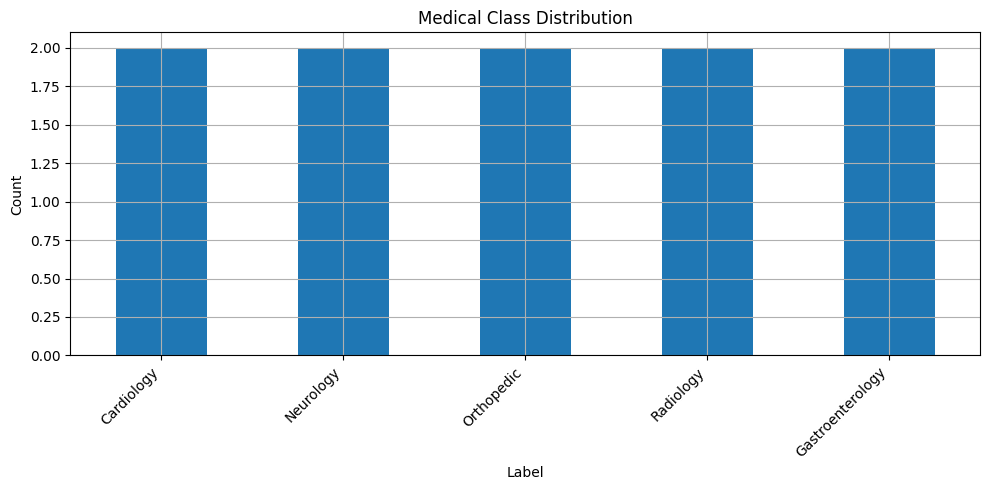

In [16]:
df["label"].value_counts().plot(kind="bar")
plt.title("Medical Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### **Create Text Length Features**

In [17]:
df["text_char_len"] = df["clinical_text"].astype(str).str.len()
df["text_word_len"] = df["clinical_text"].astype(str).str.split().str.len()
df[["text_char_len", "text_word_len"]].describe().T

,count,mean,std,min,25%,50%,75%,max
text_char_len,10.0,82.2,10.075272,67.0,77.50,82.0,87.50,101.0
text_word_len,10.0,11.1,1.791957,8.0,10.25,11.0,11.75,15.0


### **Plot Clinical Text Word Length Distribution**

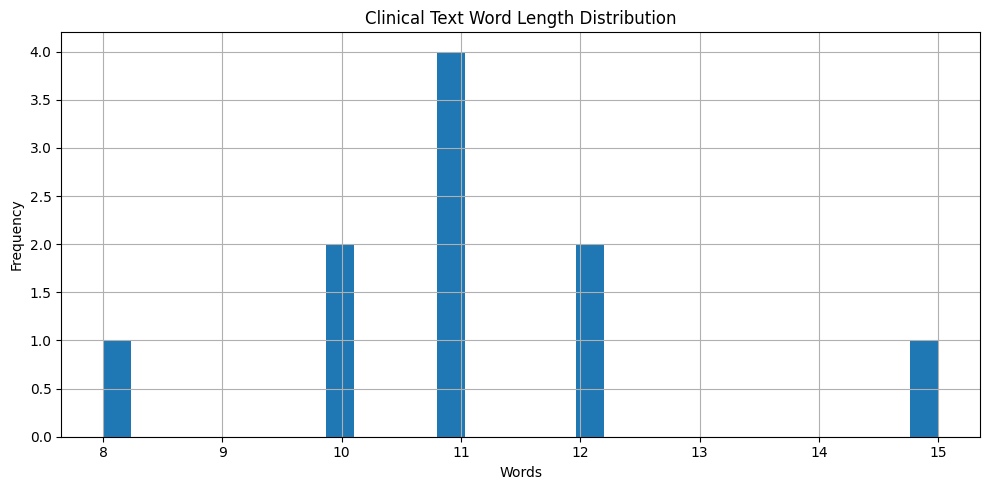

In [18]:
df["text_word_len"].hist(bins=30)
plt.title("Clinical Text Word Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### **Display Random Clinical Note Samples**

In [19]:
df.sample(min(5, len(df)), random_state=SEED)[["label", "clinical_text"]]

,label,clinical_text
8,Gastroenterology,"Patient complains of abdominal pain, reflux symptoms, and nausea after meals."
1,Cardiology,History of hypertension and palpitations. Echocardiogram recommended for further evaluation.
5,Orthopedic,Fracture follow-up note showing stable alignment and improving range of motion.
0,Cardiology,Patient presents with chest pain and shortness of breath. ECG changes suggest ischemic heart disease.
7,Radiology,CT scan demonstrates no acute intracranial hemorrhage and stable ventricular size.


### **Define Clinical Text Cleaning Function**

In [20]:
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

### **Clean Clinical Notes**

In [21]:
df["text_clean"] = df["clinical_text"].apply(clean_text)
df[["clinical_text", "text_clean"]].head(3)

,clinical_text,text_clean
0,Patient presents with chest pain and shortness of breath. ECG changes suggest ischemic heart disease.,patient presents with chest pain and shortness of breath ecg changes suggest ischemic heart disease
1,History of hypertension and palpitations. Echocardiogram recommended for further evaluation.,history of hypertension and palpitations echocardiogram recommended for further evaluation
2,Patient reports recurrent headaches and dizziness with possible migraine symptoms.,patient reports recurrent headaches and dizziness with possible migraine symptoms


### **Estimate Vocabulary Size**

In [22]:
all_tokens = " ".join(df["text_clean"].tolist()).split()
vocab_size_est = len(set(all_tokens))
print("Estimated vocabulary size:", vocab_size_est)

Estimated vocabulary size: 89


### **Inspect Most Common Tokens**

In [23]:
pd.DataFrame(Counter(all_tokens).most_common(25), columns=["token", "count"])

,token,count
0,and,9
1,with,4
2,of,4
3,patient,3
4,pain,3
5,chest,2
6,symptoms,2
7,stable,2
8,mild,2
9,no,2


### **Filter Very Rare Classes if Needed**

In [24]:
label_counts = df["label"].value_counts()
valid_labels = label_counts[label_counts >= MIN_CLASS_COUNT].index.tolist()
df = df[df["label"].isin(valid_labels)].reset_index(drop=True)
print(df.shape)
print(df["label"].nunique(), "classes retained")

(10, 5)
5 classes retained


### **Recheck Class Distribution After Filtering**

In [25]:
df["label"].value_counts()

label
Cardiology          2
Neurology           2
Orthopedic          2
Radiology           2
Gastroenterology    2
Name: count, dtype: int64

### **Encode Labels to Integers**

In [26]:
label_to_id = {label: idx for idx, label in enumerate(sorted(df["label"].unique()))}
id_to_label = {idx: label for label, idx in label_to_id.items()}

df["label_id"] = df["label"].map(label_to_id)
df[["label", "label_id"]].drop_duplicates().sort_values("label_id")

,label,label_id
0,Cardiology,0
8,Gastroenterology,1
2,Neurology,2
4,Orthopedic,3
6,Radiology,4


### **Compute Number of Classes**

In [27]:
num_classes = df["label_id"].nunique()
print("Number of classes:", num_classes)

Number of classes: 5


### **Initialize Tokenizer**

In [28]:
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df["text_clean"].tolist())
print("Tokenizer fitted successfully.")

Tokenizer fitted successfully.


### **Inspect Vocabulary Size after Tokenization**

In [29]:
vocab_size = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)
print("Vocabulary size used:", vocab_size)

Vocabulary size used: 91


### **Convert Text to Sequences**

In [30]:
df["text_seq"] = tokenizer.texts_to_sequences(df["text_clean"].tolist())
df[["text_clean", "text_seq"]].head(2)

,text_clean,text_seq
0,patient presents with chest pain and shortness of breath ecg changes suggest ischemic heart disease,"[5, 12, 3, 7, 6, 2, 13, 4, 14, 15, 16, 17, 18, 19, 20]"
1,history of hypertension and palpitations echocardiogram recommended for further evaluation,"[21, 4, 22, 2, 23, 24, 25, 26, 27, 28]"


### **Analyze Sequence Lengths**

In [31]:
seq_lengths = df["text_seq"].apply(len)
pd.Series(seq_lengths).describe()

count    10.000000
mean     11.200000
std       1.813529
min       8.000000
25%      10.250000
50%      11.000000
75%      12.000000
max      15.000000
Name: text_seq, dtype: float64

### **Plot Sequence Length Distribution**

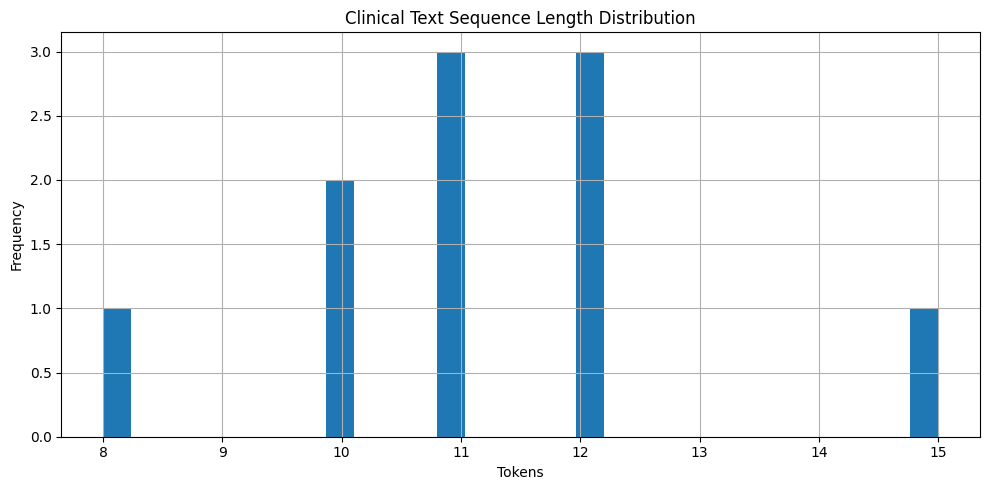

In [32]:
pd.Series(seq_lengths).hist(bins=30)
plt.title("Clinical Text Sequence Length Distribution")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### **Pad Sequences**

In [33]:
X = pad_sequences(
    df["text_seq"].tolist(),
    maxlen=MAX_SEQ_LEN,
    padding="post",
    truncating="post"
)
X.shape

(10, 300)

### **Create Target Array**

In [34]:
y = df["label_id"].values
y[:10]

array([0, 0, 2, 2, 3, 3, 4, 4, 1, 1], dtype=int64)

### **Create One-Hot Encoded Targets**

In [35]:
y_onehot = tf.keras.utils.to_categorical(y, num_classes=num_classes)
y_onehot[:3]

array([[1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

### **Split into Train and Temp Sets**

In [36]:
# Robust first split:
# - Use stratification when possible
# - If the requested split is too small for the number of classes, enlarge it
#   to at least one sample per class so train_test_split can run safely.

n_samples = len(X)
n_classes_present = len(np.unique(y))
requested_temp_size = 0.30

min_temp_count_for_stratify = n_classes_present
actual_temp_count = int(np.ceil(n_samples * requested_temp_size))

if actual_temp_count < min_temp_count_for_stratify:
    adjusted_temp_size = min_temp_count_for_stratify / n_samples
    print(
        f"Adjusted first split test_size from {requested_temp_size:.2f} "
        f"to {adjusted_temp_size:.2f} so stratification works with {n_classes_present} classes."
    )
else:
    adjusted_temp_size = requested_temp_size

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_onehot,
    test_size=adjusted_temp_size,
    random_state=SEED,
    stratify=y
)
print(X_train.shape, X_temp.shape)


Adjusted first split test_size from 0.30 to 0.50 so stratification works with 5 classes.
(5, 300) (5, 300)


### **Split Temp into Validation and Test Sets**

In [37]:
temp_labels = np.argmax(y_temp, axis=1)

# Robust second split:
# - Stratify only if each class in the temp set has at least 2 samples
# - Otherwise fall back to a regular split to avoid failure on very small datasets.

temp_class_counts = pd.Series(temp_labels).value_counts()
can_stratify_second_split = (
    len(np.unique(temp_labels)) > 1 and temp_class_counts.min() >= 2
)

if can_stratify_second_split:
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=SEED,
        stratify=temp_labels
    )
    print("Used stratified split for validation/test.")
else:
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=SEED,
        stratify=None
    )
    print("Used non-stratified split for validation/test because the temp set is too small per class.")

print(X_val.shape, X_test.shape)


Used non-stratified split for validation/test because the temp set is too small per class.
(2, 300) (3, 300)


### **Create Metadata DataFrames for Analysis**

In [38]:
# Keep the same overall 70/15/15 intent, but make the split robust for small datasets.
df_for_split = df.reset_index(drop=True)
n_classes = df_for_split["label_id"].nunique()

# For stratified splitting, the temp/test bucket must contain at least one sample per class.
requested_temp_frac = 0.30
min_temp_frac = n_classes / len(df_for_split)
temp_frac = max(requested_temp_frac, min_temp_frac)

train_meta_df, temp_meta_df = train_test_split(
    df_for_split,
    test_size=temp_frac,
    random_state=SEED,
    stratify=df_for_split["label_id"]
)

temp_meta_df = temp_meta_df.reset_index(drop=True)
temp_meta_labels = temp_meta_df["label_id"].values

# Use stratify for the val/test split only when each class in temp has at least 2 samples.
temp_label_counts = temp_meta_df["label_id"].value_counts()
can_stratify_temp = (
    temp_meta_df["label_id"].nunique() > 1
    and temp_label_counts.min() >= 2
)

val_meta_df, test_meta_df = train_test_split(
    temp_meta_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_meta_labels if can_stratify_temp else None
)

val_meta_df = val_meta_df.reset_index(drop=True)
test_meta_df = test_meta_df.reset_index(drop=True)

print("Using temp split fraction:", round(temp_frac, 4))
print("Train:", train_meta_df.shape, "Val:", val_meta_df.shape, "Test:", test_meta_df.shape)

Using temp split fraction: 0.5
Train: (5, 7) Val: (2, 7) Test: (3, 7)


### **Compute Class Weights for Imbalance Handling**

In [39]:
train_label_ids = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_label_ids),
    y=train_label_ids
)
class_weight_dict = {i: float(w) for i, w in enumerate(class_weights)}
class_weight_dict

{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}

### **Define a Simple Attention Layer**

In [40]:
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True,
            name="attention_weight"
        )
        self.b = self.add_weight(
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True,
            name="attention_bias"
        )
        super().build(input_shape)

    def call(self, inputs):
        score = tf.tanh(tf.matmul(inputs, self.W) + self.b)
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * inputs
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector

### **Build the BiLSTM with Attention Model**

In [41]:
text_input = Input(shape=(MAX_SEQ_LEN,), name="clinical_text_input")
x = Embedding(vocab_size, EMBEDDING_DIM, name="embedding")(text_input)
x = Bidirectional(LSTM(LSTM_UNITS, return_sequences=True), name="bilstm")(x)
x = AttentionLayer(name="attention")(x)
x = Dropout(DROPOUT_RATE, name="dropout_1")(x)
x = Dense(128, activation="relu", name="dense_1")(x)
x = Dropout(0.20, name="dropout_2")(x)
output = Dense(num_classes, activation="softmax", name="class_output")(x)

model = Model(inputs=text_input, outputs=output, name="medical_text_bilstm_attention_classifier")
model.summary()

Model: "medical_text_bilstm_attention_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ clinical_text_input (InputLayer)     │ (None, 300)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 300, 128)            │          11,648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bilstm (Bidirectional)               │ (None, 300, 128)            │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention (AttentionLayer)           │ (None, 128)                 │             428 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ class_output (Dense)                 │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 128,049 (500.19 KB)

 Trainable params: 128,049 (500.19 KB)

 Non-trainable params: 0 (0.00 B)

### **Print a Simple Model Architecture Diagram**

In [42]:
architecture_diagram = '''
Clinical Text ─► Tokenizer ─► Embedding ─► BiLSTM ─► Attention ─► Dense Layers ─► Specialty Class
'''
print(architecture_diagram)


Clinical Text ─► Tokenizer ─► Embedding ─► BiLSTM ─► Attention ─► Dense Layers ─► Specialty Class



### **Compile the Model**

In [43]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


### **Create Training Callbacks**

In [44]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-5
    )
]

print("Callbacks ready.")

Callbacks ready.


### **Train the Clinical NLP Model**

In [45]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4000 - loss: 1.6065 - val_accuracy: 0.0000e+00 - val_loss: 1.6388 - learning_rate: 0.0010
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.2000 - loss: 1.5941 - val_accuracy: 0.0000e+00 - val_loss: 1.6467 - learning_rate: 0.0010
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.2000 - loss: 1.6116 - val_accuracy: 0.0000e+00 - val_loss: 1.6520 - learning_rate: 5.0000e-04


### **Convert Training History to DataFrame**

In [46]:
history_df = pd.DataFrame(history.history)
history_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.4,1.606459,0.0,1.638831,0.0010
1,0.2,1.594105,0.0,1.646722,0.0010
2,0.2,1.611589,0.0,1.651978,0.0005


### **Plot Training and Validation Loss**

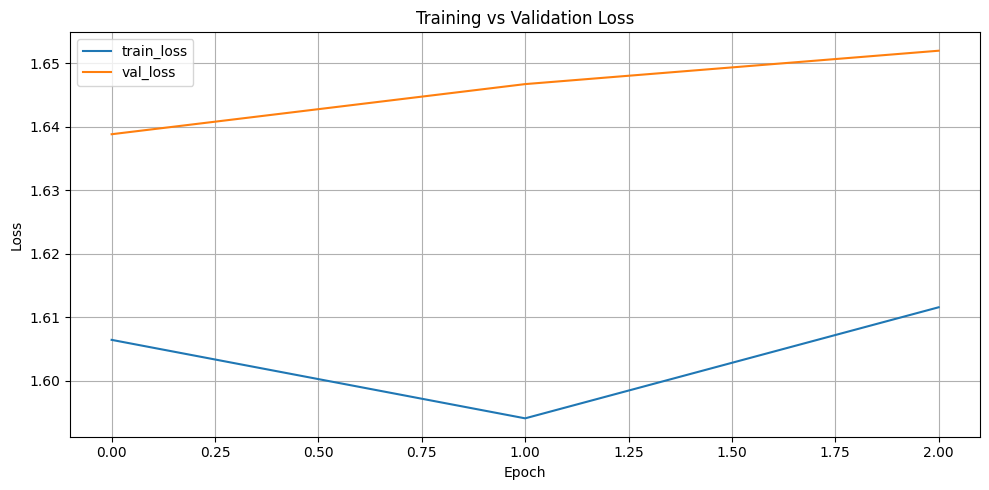

In [47]:
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

### **Plot Training and Validation Accuracy**

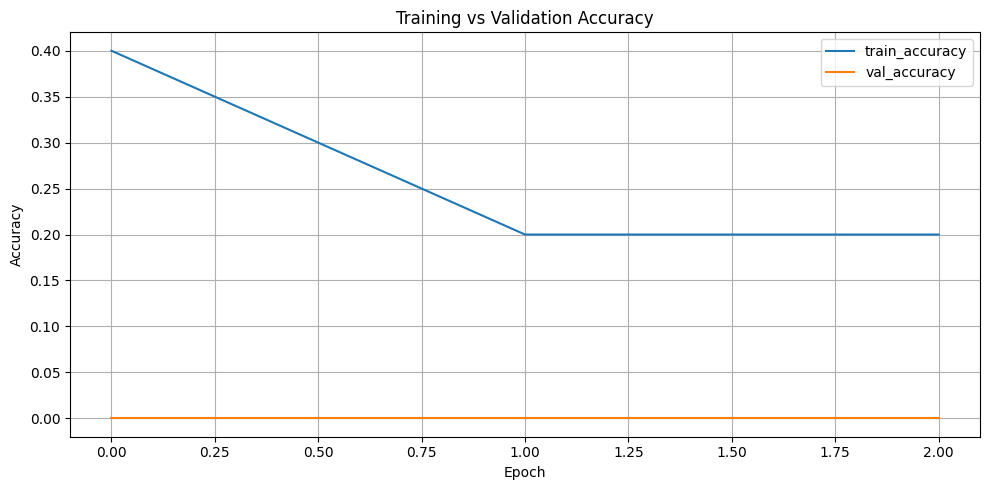

In [48]:
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### **Evaluate on the Test Set**

In [49]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print({"test_loss": round(float(test_loss), 4), "test_accuracy": round(float(test_accuracy), 4)})

{'test_loss': 1.5904, 'test_accuracy': 0.3333}


### **Generate Test Predictions**

In [50]:
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print(y_pred[:10])
print(y_true[:10])

[3 3 3]
[0 2 3]


### **Compute Weighted Precision, Recall, and F1**

In [51]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

metrics_dict = {
    "accuracy": accuracy_score(y_true, y_pred),
    "weighted_precision": precision,
    "weighted_recall": recall,
    "weighted_f1_score": f1
}
metrics_dict

{'accuracy': 0.3333333333333333,
 'weighted_precision': 0.1111111111111111,
 'weighted_recall': 0.3333333333333333,
 'weighted_f1_score': 0.16666666666666666}

### **Display Classification Report**

In [52]:
target_labels = list(sorted(id_to_label.keys()))
target_names = [id_to_label[i] for i in target_labels]
print(
    classification_report(
        y_true,
        y_pred,
        labels=target_labels,
        target_names=target_names,
        zero_division=0
    )
)


                  precision    recall  f1-score   support

      Cardiology       0.00      0.00      0.00         1
Gastroenterology       0.00      0.00      0.00         0
       Neurology       0.00      0.00      0.00         1
      Orthopedic       0.33      1.00      0.50         1
       Radiology       0.00      0.00      0.00         0

        accuracy                           0.33         3
       macro avg       0.07      0.20      0.10         3
    weighted avg       0.11      0.33      0.17         3



### **Create Confusion Matrix Table**

In [53]:
cm = confusion_matrix(y_true, y_pred, labels=target_labels)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
cm_df


,Cardiology,Gastroenterology,Neurology,Orthopedic,Radiology
Cardiology,0,0,0,1,0
Gastroenterology,0,0,0,0,0
Neurology,0,0,0,1,0
Orthopedic,0,0,0,1,0
Radiology,0,0,0,0,0


### **Visualize Confusion Matrix**

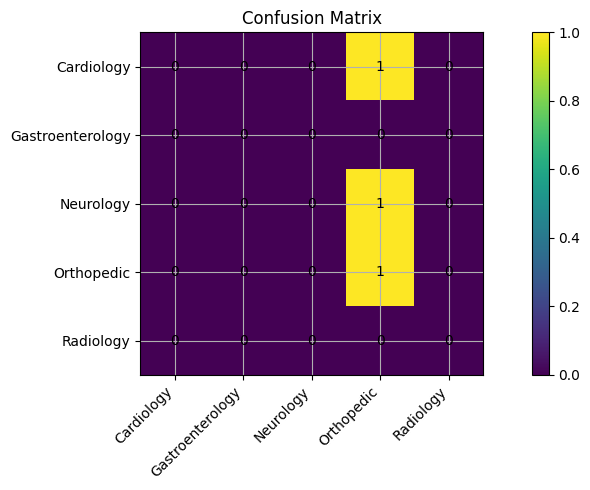

In [54]:
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(target_names)), target_names, rotation=45, ha="right")
plt.yticks(range(len(target_names)), target_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

### **Create Prediction Analysis DataFrame**

In [55]:
prediction_df = test_meta_df.copy().reset_index(drop=True)
prediction_df["true_label_id"] = y_true
prediction_df["pred_label_id"] = y_pred
prediction_df["true_label_name"] = prediction_df["true_label_id"].map(id_to_label)
prediction_df["pred_label_name"] = prediction_df["pred_label_id"].map(id_to_label)
prediction_df["is_correct"] = (prediction_df["true_label_id"] == prediction_df["pred_label_id"]).astype(int)
prediction_df["confidence"] = y_pred_prob.max(axis=1)
prediction_df.head()

,label,clinical_text,text_char_len,text_word_len,text_clean,label_id,text_seq,true_label_id,pred_label_id,true_label_name,pred_label_name,is_correct,confidence
0,Cardiology,Patient presents with chest pain and shortness of breath. ECG changes suggest ischemic heart disease.,101,15,patient presents with chest pain and shortness of breath ecg changes suggest ischemic heart disease,0,"[5, 12, 3, 7, 6, 2, 13, 4, 14, 15, 16, 17, 18, 19, 20]",0,3,Cardiology,Orthopedic,0,0.205773
1,Neurology,Patient reports recurrent headaches and dizziness with possible migraine symptoms.,82,10,patient reports recurrent headaches and dizziness with possible migraine symptoms,2,"[5, 29, 30, 31, 2, 32, 3, 33, 34, 8]",2,3,Neurology,Orthopedic,0,0.205864
2,Orthopedic,Knee pain worsened with movement. MRI suggests meniscal injury and ligament strain.,83,12,knee pain worsened with movement mri suggests meniscal injury and ligament strain,3,"[46, 6, 47, 3, 48, 49, 50, 51, 52, 2, 53, 54]",3,3,Orthopedic,Orthopedic,1,0.205779


### **Review Most Confident Correct Predictions**

In [56]:
prediction_df.sort_values(["is_correct", "confidence"], ascending=[False, False]).head(10)

,label,clinical_text,text_char_len,text_word_len,text_clean,label_id,text_seq,true_label_id,pred_label_id,true_label_name,pred_label_name,is_correct,confidence
2,Orthopedic,Knee pain worsened with movement. MRI suggests meniscal injury and ligament strain.,83,12,knee pain worsened with movement mri suggests meniscal injury and ligament strain,3,"[46, 6, 47, 3, 48, 49, 50, 51, 52, 2, 53, 54]",3,3,Orthopedic,Orthopedic,1,0.205779
1,Neurology,Patient reports recurrent headaches and dizziness with possible migraine symptoms.,82,10,patient reports recurrent headaches and dizziness with possible migraine symptoms,2,"[5, 29, 30, 31, 2, 32, 3, 33, 34, 8]",2,3,Neurology,Orthopedic,0,0.205864
0,Cardiology,Patient presents with chest pain and shortness of breath. ECG changes suggest ischemic heart disease.,101,15,patient presents with chest pain and shortness of breath ecg changes suggest ischemic heart disease,0,"[5, 12, 3, 7, 6, 2, 13, 4, 14, 15, 16, 17, 18, 19, 20]",0,3,Cardiology,Orthopedic,0,0.205773


### **Review Most Confident Incorrect Predictions**

In [57]:
prediction_df.sort_values(["is_correct", "confidence"], ascending=[True, False]).head(10)

,label,clinical_text,text_char_len,text_word_len,text_clean,label_id,text_seq,true_label_id,pred_label_id,true_label_name,pred_label_name,is_correct,confidence
1,Neurology,Patient reports recurrent headaches and dizziness with possible migraine symptoms.,82,10,patient reports recurrent headaches and dizziness with possible migraine symptoms,2,"[5, 29, 30, 31, 2, 32, 3, 33, 34, 8]",2,3,Neurology,Orthopedic,0,0.205864
0,Cardiology,Patient presents with chest pain and shortness of breath. ECG changes suggest ischemic heart disease.,101,15,patient presents with chest pain and shortness of breath ecg changes suggest ischemic heart disease,0,"[5, 12, 3, 7, 6, 2, 13, 4, 14, 15, 16, 17, 18, 19, 20]",0,3,Cardiology,Orthopedic,0,0.205773
2,Orthopedic,Knee pain worsened with movement. MRI suggests meniscal injury and ligament strain.,83,12,knee pain worsened with movement mri suggests meniscal injury and ligament strain,3,"[46, 6, 47, 3, 48, 49, 50, 51, 52, 2, 53, 54]",3,3,Orthopedic,Orthopedic,1,0.205779


### **Analyze Accuracy by Class**

In [58]:
prediction_df.groupby("true_label_name")["is_correct"].mean().sort_values()

true_label_name
Cardiology    0.0
Neurology     0.0
Orthopedic    1.0
Name: is_correct, dtype: float64

### **Plot Accuracy by Class**

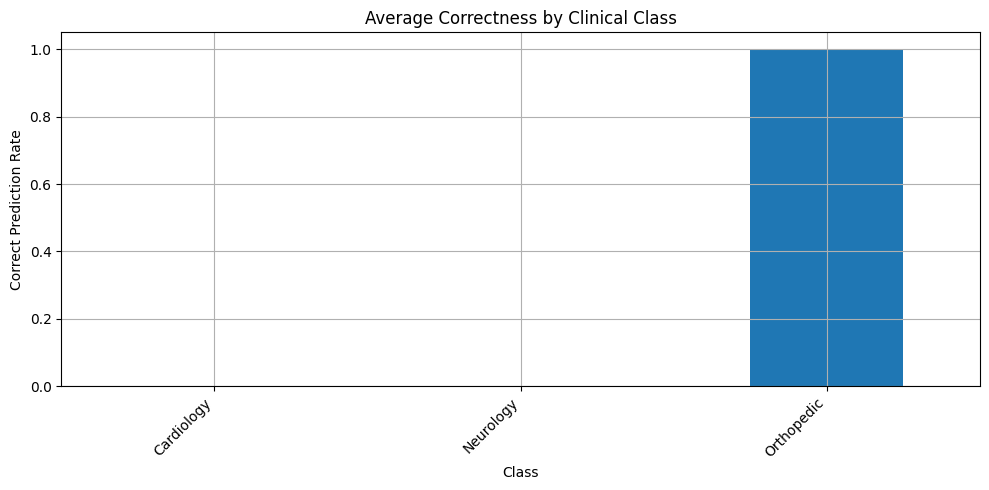

In [59]:
prediction_df.groupby("true_label_name")["is_correct"].mean().sort_values().plot(kind="bar")
plt.title("Average Correctness by Clinical Class")
plt.xlabel("Class")
plt.ylabel("Correct Prediction Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### **Create Inference Utility**

In [60]:
def predict_clinical_note(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=MAX_SEQ_LEN, padding="post", truncating="post")
    probs = model.predict(pad, verbose=0)[0]
    pred_id = int(np.argmax(probs))
    pred_label = id_to_label[pred_id]
    confidence = float(np.max(probs))
    return {
        "predicted_label": pred_label,
        "confidence": confidence,
        "probabilities": {id_to_label[i]: float(probs[i]) for i in range(len(probs))}
    }

### **Test the Inference Utility**

In [61]:
predict_clinical_note(
    "Patient has chest pain with abnormal ecg findings and history of hypertension."
)

{'predicted_label': 'Orthopedic',
 'confidence': 0.20581035315990448,
 'probabilities': {'Cardiology': 0.20489533245563507,
  'Gastroenterology': 0.19553516805171967,
  'Neurology': 0.20086424052715302,
  'Orthopedic': 0.20581035315990448,
  'Radiology': 0.19289492070674896}}

### **Create Sample Output Table**

In [62]:
sample_outputs = []
for txt in test_meta_df["text_clean"].head(min(5, len(test_meta_df))).tolist():
    pred = predict_clinical_note(txt)
    sample_outputs.append({
        "text": txt,
        "predicted_label": pred["predicted_label"],
        "confidence": pred["confidence"]
    })

pd.DataFrame(sample_outputs)

,text,predicted_label,confidence
0,patient presents with chest pain and shortness of breath ecg changes suggest ischemic heart disease,Orthopedic,0.205773
1,patient reports recurrent headaches and dizziness with possible migraine symptoms,Orthopedic,0.205865
2,knee pain worsened with movement mri suggests meniscal injury and ligament strain,Orthopedic,0.205779


### **Save Model Artifacts**

In [63]:
model.save(MODEL_DIR / "medical_text_bilstm_attention_model.keras")
with open(ARTIFACT_DIR / "tokenizer_config.json", "w", encoding="utf-8") as f:
    json.dump(tokenizer.to_json(), f)

with open(ARTIFACT_DIR / "label_mapping.json", "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in id_to_label.items()}, f)

print("Model artifacts saved successfully.")

Model artifacts saved successfully.


### **Save Prediction Outputs**

In [64]:
prediction_df.to_csv(PRED_DIR / "medical_text_prediction_analysis.csv", index=False)
history_df.to_csv(PRED_DIR / "medical_text_training_history.csv", index=False)

print("Prediction outputs saved.")

Prediction outputs saved.


### **Reload the Saved Model**

In [65]:
reloaded_model = tf.keras.models.load_model(
    MODEL_DIR / "medical_text_bilstm_attention_model.keras",
    custom_objects={"AttentionLayer": AttentionLayer}
)
print("Reloaded model successfully.")

Reloaded model successfully.


### **Run Reload Validation**

In [66]:
reload_probs = reloaded_model.predict(X_test[:10], verbose=0)
reload_probs[:2]

array([[0.20488267, 0.19558379, 0.20082645, 0.20577344, 0.19293362],
       [0.20488182, 0.1955087 , 0.20087771, 0.20586449, 0.1928673 ]],
      dtype=float32)

### **Create Deployment Demo Function**

In [67]:
def clinical_demo(note_text):
    return predict_clinical_note(note_text)

### **Test Deployment Demo Function**

In [68]:
clinical_demo(
    "CT scan shows no acute bleed and patient has persistent neurological deficits."
)

{'predicted_label': 'Orthopedic',
 'confidence': 0.20582279562950134,
 'probabilities': {'Cardiology': 0.20483025908470154,
  'Gastroenterology': 0.19555939733982086,
  'Neurology': 0.2009388655424118,
  'Orthopedic': 0.20582279562950134,
  'Radiology': 0.19284860789775848}}

### **Create Optional Streamlit App Code**

In [69]:
streamlit_app_code = '''
import streamlit as st

st.title("Clinical Text Classification Demo")
note_text = st.text_area("Enter Clinical Note")

if st.button("Predict"):
    st.write("Load the saved model and display predicted specialty here.")
'''
print(streamlit_app_code)


import streamlit as st

st.title("Clinical Text Classification Demo")
note_text = st.text_area("Enter Clinical Note")

if st.button("Predict"):
    st.write("Load the saved model and display predicted specialty here.")



### **Final Project Summary for Notebook Report**

In [70]:
final_project_notes = {
    "project_title": "Medical Text Classification using Bi-Directional LSTM",
    "dataset": "Medical Transcriptions Dataset",
    "model_type": "BiLSTM + Attention",
    "core_goal": "Classify clinical notes into healthcare categories using contextual sequence modeling.",
    "deployment_ready": True,
    "includes_demo": True
}
final_project_notes

{'project_title': 'Medical Text Classification using Bi-Directional LSTM',
 'dataset': 'Medical Transcriptions Dataset',
 'model_type': 'BiLSTM + Attention',
 'core_goal': 'Classify clinical notes into healthcare categories using contextual sequence modeling.',
 'deployment_ready': True,
 'includes_demo': True}

### **Conclusion**

In [71]:
print(
    "This notebook built an end-to-end clinical NLP workflow with dataset analysis, "
    "text cleaning, tokenization, class imbalance handling, BiLSTM plus attention modeling, "
    "evaluation, error analysis, and an optional deployment demo."
)

This notebook built an end-to-end clinical NLP workflow with dataset analysis, text cleaning, tokenization, class imbalance handling, BiLSTM plus attention modeling, evaluation, error analysis, and an optional deployment demo.
